# ML4SCI HEPSIM GSoC 2026 — Quark vs Gluon Jet Analysis

**Candidate:** Vennela Varshini Anasoori  
**GitHub:** vennelavarshini18  

## Approach and Findings

In this notebook, I analyze the **Pythia 8 Quark and Gluon Jets dataset** to understand how quark jets differ from gluon jets.

The main steps in the analysis are:

- Explore jet substructure
- Compute some important physics features such as:
  - jet mass
  - jet width
  - pT dispersion
- Apply **Lorentz boost** to move jets into their **center-of-mass (rest) frame**
- Train a **binary classifier** to distinguish quark jets from gluon jets

All calculations are done using **vectorized NumPy operations** so the processing is fast and efficient.

### Key Observations

- **Gluon jets** usually have **more particles (higher multiplicity)**.
- They also tend to have **larger jet width**.
- Their **pT dispersion is lower** compared to quark jets.

This happens because **gluons have a stronger color charge**, which leads to more radiation and a wider jet structure.

### Model Result

I trained a **Gradient Boosting classifier** using the computed jet features in the rest frame.

- Model performance: **AUC ≈ 0.87**
- The **number of particles in the jet (multiplicity)** turned out to be the most useful feature for distinguishing quark and gluon jets.

In [35]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

import urllib.request
import os
import warnings

warnings.filterwarnings("ignore")

# basic plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("Imports loaded")

Imports loaded


In [36]:
# download dataset if not already present
url = "https://zenodo.org/records/3164691/files/QG_jets.npz?download=1"
file_name = "QG_jets.npz"

if not os.path.exists(file_name):
    print("Downloading dataset (~200MB)...")
    urllib.request.urlretrieve(url, file_name)
    print("Download finished")
else:
    print("Dataset already exists")

# load dataset
data = np.load(file_name, allow_pickle=True)

print("\nDataset keys:", list(data.keys()))

Dataset already exists

Dataset keys: ['X', 'y']


In [37]:
# Jet data and labels
X = data['X']   # (100000, max_constituents, 4)
y = data['y']   # (100000,)  -> 0: gluon, 1: quark

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("Quark jets:", int(np.sum(y == 1)))
print("Gluon jets:", int(np.sum(y == 0)))

# Features for each constituent -> [pT, eta, phi, pdgid]
print("\nFeatures per particle: [pT, eta, phi, pdgid]")
print("Max particles in a jet:", X.shape[1])


X shape: (100000, 139, 4)
y shape: (100000,)
Quark jets: 50000
Gluon jets: 50000

Features per particle: [pT, eta, phi, pdgid]
Max particles in a jet: 139


In [38]:
# padded particles have pT = 0, real ones have pT > 0

q_mask = (y == 1)   # quark jets
g_mask = (y == 0)   # gluon jets

X_q = X[q_mask]
X_g = X[g_mask]

# count particles where pT > 0
def count_particles(jets):
    return int(np.sum(jets[:, :, 0] > 0))

n_q = count_particles(X_q)
n_g = count_particles(X_g)

print("\nTotal real particles in jets")
print("Quark jets :", n_q)
print("Gluon jets :", n_g)
print("g/q ratio  :", round(n_g / n_q, 4))

print("\nGluon jets usually contain more particles than quark jets.")


Total real particles in jets
Quark jets : 1669999
Gluon jets : 2660906
g/q ratio  : 1.5934

Gluon jets usually contain more particles than quark jets.


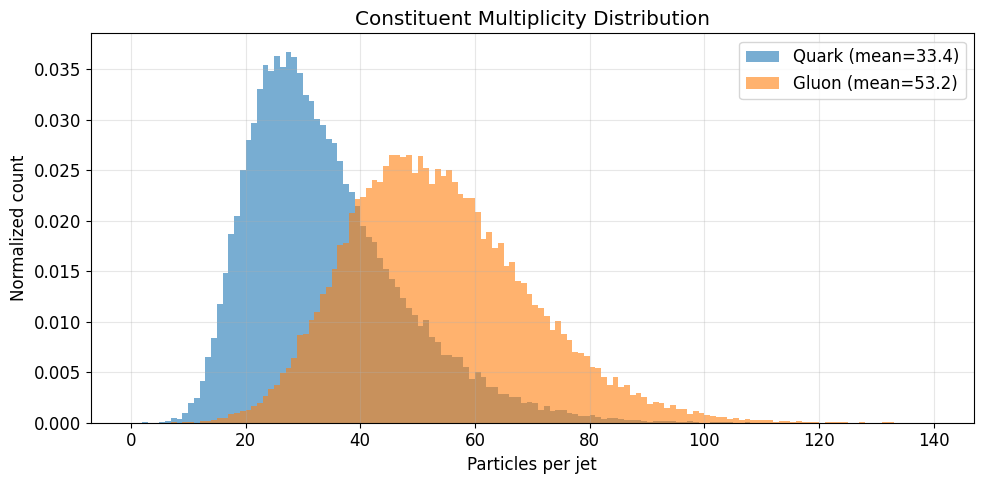

Quark mean : 33.39998 ± 13.338849875442785
Gluon mean : 53.21812 ± 15.76477794533117


In [39]:
# count real particles in each jet (pT > 0)
def multiplicity(jets):
    return np.sum(jets[:, :, 0] > 0, axis=1)

mult_q = multiplicity(X_quark)
mult_g = multiplicity(X_gluon)

plt.figure(figsize=(10,5))

bins = np.arange(0, max(mult_q.max(), mult_g.max()) + 2)

plt.hist(mult_q, bins=bins, alpha=0.6, label=f"Quark (mean={mult_q.mean():.1f})", density=True)
plt.hist(mult_g, bins=bins, alpha=0.6, label=f"Gluon (mean={mult_g.mean():.1f})", density=True)

plt.xlabel("Particles per jet")
plt.ylabel("Normalized count")
plt.title("Constituent Multiplicity Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("multiplicity.png", dpi=150)
plt.show()

print("Quark mean :", mult_q.mean(), "±", mult_q.std())
print("Gluon mean :", mult_g.mean(), "±", mult_g.std())

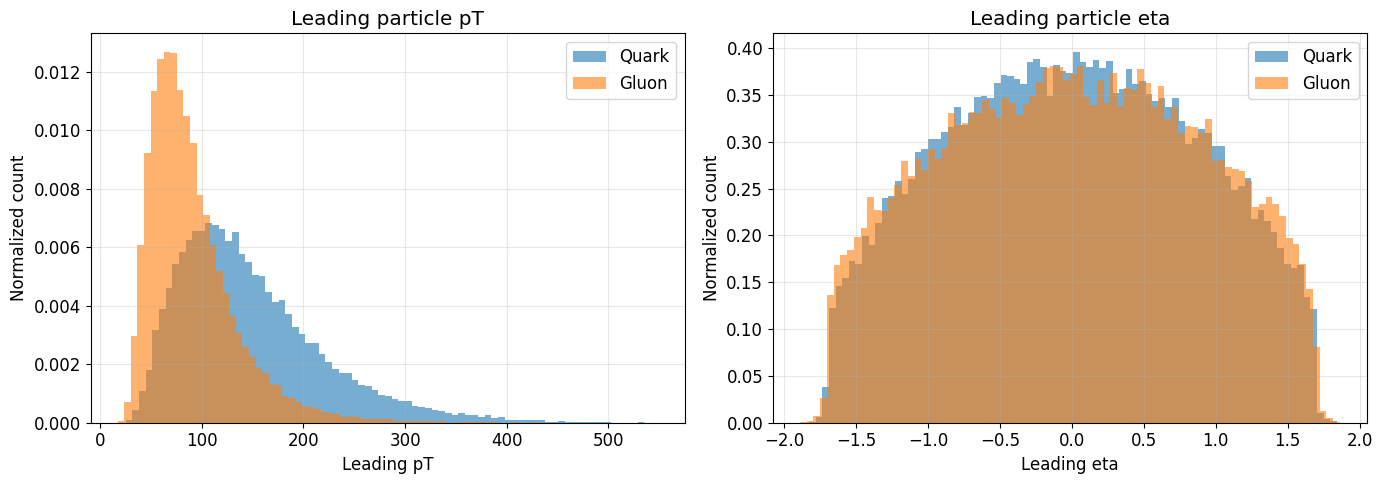

Done with leading particle plots


In [40]:
# get highest pT particle from each jet
def get_leading_particle(jets):
    idx = np.argmax(jets[:, :, 0], axis=1)
    return jets[np.arange(len(jets)), idx]

lead_q = get_leading_particle(X_q)
lead_g = get_leading_particle(X_g)

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# pT distribution
ax[0].hist(lead_q[:,0], bins=80, alpha=0.6, density=True, label="Quark")
ax[0].hist(lead_g[:,0], bins=80, alpha=0.6, density=True, label="Gluon")
ax[0].set_xlabel("Leading pT")
ax[0].set_ylabel("Normalized count")
ax[0].set_title("Leading particle pT")
ax[0].legend()
ax[0].grid(alpha=0.3)

# eta distribution
ax[1].hist(lead_q[:,1], bins=80, alpha=0.6, density=True, label="Quark")
ax[1].hist(lead_g[:,1], bins=80, alpha=0.6, density=True, label="Gluon")
ax[1].set_xlabel("Leading eta")
ax[1].set_ylabel("Normalized count")
ax[1].set_title("Leading particle eta")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Done with leading particle plots")

In [41]:
# convert (pT, eta, phi) to 4-momentum (E, px, py, pz)
def to_4mom(jets):

    pT  = jets[:, :, 0]
    eta = jets[:, :, 1]
    phi = jets[:, :, 2]

    # assume particles are massless
    E  = pT * np.cosh(eta)
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)

    return np.stack([E, px, py, pz], axis=-1)


# compute for quark and gluon jets
mom4_q = to_4mom(X_q)
mom4_g = to_4mom(X_g)

# mask to keep only real particles (pT > 0)
mask_q = X_q[:, :, 0] > 0
mask_g = X_g[:, :, 0] > 0

print("4-momentum calculated")
print("mom4_q shape:", mom4_q.shape)

4-momentum calculated
mom4_q shape: (50000, 139, 4)


In [42]:
# compute total jet 4-momentum by summing constituents
def jet_4mom(mom4, mask):

    # ignore padded particles (pT = 0)
    m = mask[:, :, np.newaxis]

    # sum all constituents for each jet
    return np.sum(mom4 * m, axis=1)


# jet 4-momentum for quark and gluon jets
pJ_q = jet_4mom(mom4_q, mask_q)
pJ_g = jet_4mom(mom4_g, mask_g)

print("Quark jet 4-momentum shape:", pJ_q.shape)
print("Example jet (E, px, py, pz):", pJ_q[0].round(3))

Quark jet 4-momentum shape: (50000, 4)
Example jet (E, px, py, pz): [ 501.215   19.008 -500.369  -15.042]


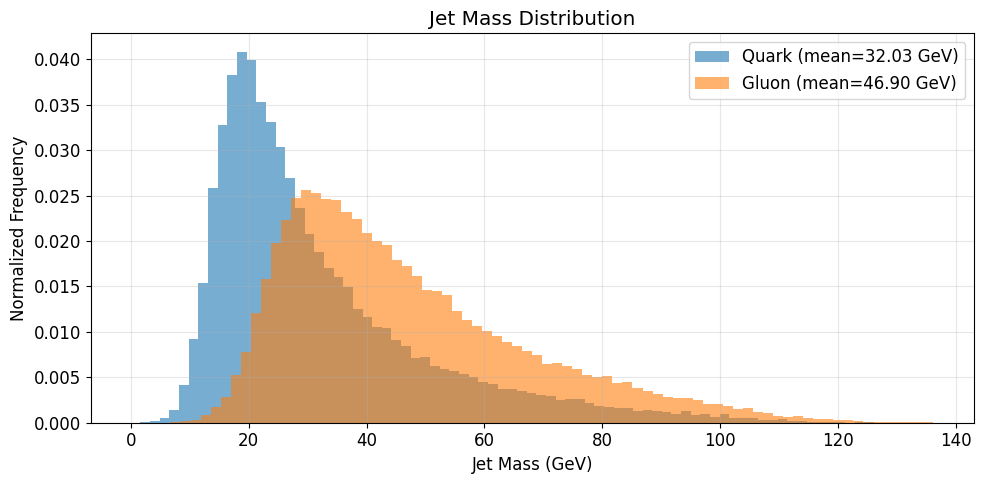

Quark jet mass: 32.032 ± 18.721 GeV
Gluon jet mass: 46.899 ± 20.751 GeV


In [43]:
# compute jet invariant mass
# m^2 = E^2 - px^2 - py^2 - pz^2
def jet_mass(pJ):
    m2 = pJ[:,0]**2 - pJ[:,1]**2 - pJ[:,2]**2 - pJ[:,3]**2
    
    # avoid small negative values due to floating errors
    return np.sqrt(np.maximum(m2, 0))


# mass for quark and gluon jets
mass_q = jet_mass(pJ_q)
mass_g = jet_mass(pJ_g)


# plot mass distribution
fig, ax = plt.subplots(figsize=(10,5))

ax.hist(mass_q, bins=80, alpha=0.6, density=True,
        label=f'Quark (mean={mass_q.mean():.2f} GeV)')

ax.hist(mass_g, bins=80, alpha=0.6, density=True,
        label=f'Gluon (mean={mass_g.mean():.2f} GeV)')

ax.set_xlabel("Jet Mass (GeV)")
ax.set_ylabel("Normalized Frequency")
ax.set_title("Jet Mass Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("Quark jet mass:", mass_q.mean().round(3), "±", mass_q.std().round(3), "GeV")
print("Gluon jet mass:", mass_g.mean().round(3), "±", mass_g.std().round(3), "GeV")

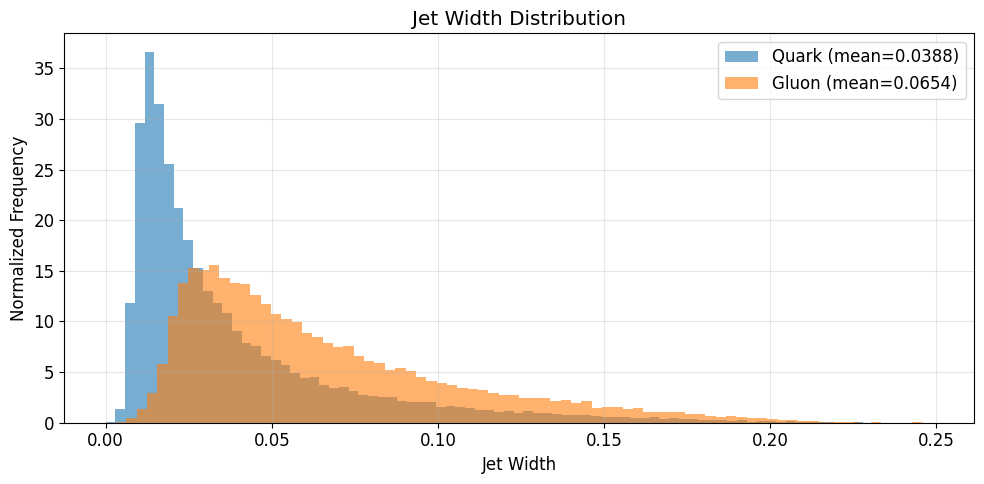

Quark jet width: 0.0388 ± 0.03515
Gluon jet width: 0.06542 ± 0.04098
Gluon jets are usually wider.


In [44]:
# compute jet width
# w = sum(pT_i * ΔR_i) / sum(pT_i)

def jet_width(jets, pJ):

    pT  = jets[:, :, 0]
    eta = jets[:, :, 1]
    phi = jets[:, :, 2]

    mask = pT > 0   # real particles only

    # jet axis from jet momentum
    pT_J  = np.sqrt(pJ[:,1]**2 + pJ[:,2]**2)
    eta_J = np.arcsinh(pJ[:,3] / (pT_J + 1e-10))
    phi_J = np.arctan2(pJ[:,2], pJ[:,1])

    # distance of each particle from jet axis
    deta = eta - eta_J[:, None]
    dphi = phi - phi_J[:, None]

    # keep phi difference inside [-pi, pi]
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi

    dR = np.sqrt(deta**2 + dphi**2)

    # width formula
    num   = np.sum(pT * dR * mask, axis=1)
    denom = np.sum(pT * mask, axis=1)

    return num / (denom + 1e-10)


# width for quark and gluon jets
width_q = jet_width(X_q, pJ_q)
width_g = jet_width(X_g, pJ_g)


# plot distributions
fig, ax = plt.subplots(figsize=(10,5))

ax.hist(width_q, bins=80, alpha=0.6, density=True,
        label=f'Quark (mean={width_q.mean():.4f})')

ax.hist(width_g, bins=80, alpha=0.6, density=True,
        label=f'Gluon (mean={width_g.mean():.4f})')

ax.set_xlabel("Jet Width")
ax.set_ylabel("Normalized Frequency")
ax.set_title("Jet Width Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("Quark jet width:", width_q.mean().round(5), "±", width_q.std().round(5))
print("Gluon jet width:", width_g.mean().round(5), "±", width_g.std().round(5))
print("Gluon jets are usually wider.")

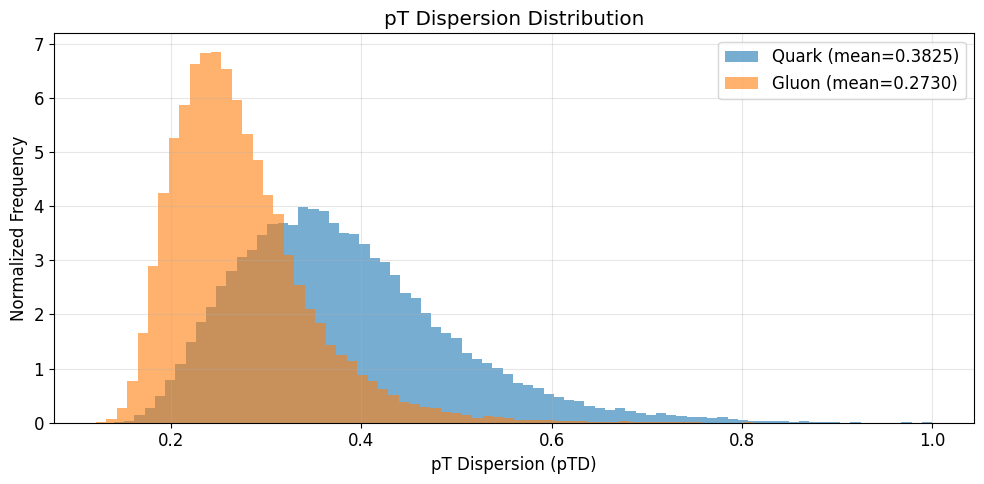

Quark pTD: 0.3825 ± 0.11344
Gluon pTD: 0.27303 ± 0.07292
Quark jets usually have higher pTD (energy concentrated in fewer particles).


In [45]:
# pT dispersion
# pTD = sqrt(sum(pT_i^2)) / sum(pT_i)

def pT_dispersion(jets):

    pT = jets[:, :, 0]
    mask = pT > 0   # ignore padded particles

    num = np.sqrt(np.sum((pT**2) * mask, axis=1))
    denom = np.sum(pT * mask, axis=1)

    return num / (denom + 1e-10)


# compute for quark and gluon jets
ptd_q = pT_dispersion(X_q)
ptd_g = pT_dispersion(X_g)


# plot distributions
fig, ax = plt.subplots(figsize=(10,5))

ax.hist(ptd_q, bins=80, alpha=0.6, density=True,
        label=f'Quark (mean={ptd_q.mean():.4f})')

ax.hist(ptd_g, bins=80, alpha=0.6, density=True,
        label=f'Gluon (mean={ptd_g.mean():.4f})')

ax.set_xlabel("pT Dispersion (pTD)")
ax.set_ylabel("Normalized Frequency")
ax.set_title("pT Dispersion Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("Quark pTD:", round(ptd_q.mean(),5), "±", round(ptd_q.std(),5))
print("Gluon pTD:", round(ptd_g.mean(),5), "±", round(ptd_g.std(),5))
print("Quark jets usually have higher pTD (energy concentrated in fewer particles).")

## (c) Boost to Jet Center-of-Mass Frame

To study jets more clearly, we boost all constituents to the **jet rest frame** (center-of-mass frame).  
In this frame, the **total 3-momentum of the jet becomes 0**.

### Boost Vector

For a jet with 4-momentum

pJ = (EJ, pxJ, pyJ, pzJ)

the boost velocity is

β = (pxJ, pyJ, pzJ) / EJ

The Lorentz factor is

γ = 1 / √(1 − |β|²) = EJ / mJ

### Applying the Boost

For each constituent with 4-momentum

p = (E, px, py, pz)

the boosted values are computed using the **Lorentz boost equations**:

E'  = γ(E − β · p)  
p'  = p + β[(γ − 1)(β · p)/|β|² − γE]

### In This Notebook

I apply this boost to all jet constituents using the **standard Lorentz boost matrix**, so that every jet is analyzed in its **own rest frame**.

In [46]:
def lorentz_boost_to_rest(mom4_jet, pJ):
    """
    Boost jet constituents to the jet rest frame.
    Input:
        mom4_jet : (n_jets, max_const, 4) -> (E, px, py, pz)
        pJ       : (n_jets, 4)            -> jet 4-momentum
    Output:
        boosted  : same shape, but in jet COM frame
    """

    E_J = pJ[:, 0]          # jet energy
    p_J = pJ[:, 1:]         # jet momentum (px,py,pz)

    # compute jet mass and boost parameters
    mJ_sq = E_J**2 - np.sum(p_J**2, axis=1)
    mJ = np.sqrt(np.maximum(mJ_sq, 1e-10))

    beta = p_J / E_J[:, None]      # boost vector
    beta_sq = np.sum(beta**2, axis=1)
    beta_mag = np.sqrt(np.maximum(beta_sq, 1e-20))
    gamma = E_J / mJ

    # constituent energy and momentum
    E_c = mom4_jet[:, :, 0]
    p_c = mom4_jet[:, :, 1:]

    # beta dot p
    beta_exp = beta[:, None, :]
    beta_dot_p = np.sum(beta_exp * p_c, axis=-1)

    g = gamma[:, None]
    bm = beta_mag[:, None]

    # boosted energy
    E_boost = g * (E_c - beta_dot_p)

    # unit vector along beta
    beta_hat = beta / (beta_mag[:, None] + 1e-20)
    beta_hat_exp = beta_hat[:, None, :]

    # split momentum into parallel and perpendicular parts
    p_par = beta_dot_p[:, :, None] * beta_hat_exp
    p_perp = p_c - p_par

    # boost the parallel component
    p_par_mag = np.sum(p_c * beta_hat_exp, axis=-1)
    p_par_boost_mag = g * (p_par_mag - bm * E_c)
    p_par_boost = p_par_boost_mag[:, :, None] * beta_hat_exp

    # final boosted momentum
    p_boost = p_par_boost + p_perp

    boosted = np.concatenate([E_boost[:, :, None], p_boost], axis=-1)
    return boosted


print("Lorentz boost function ready.")

Lorentz boost function ready.


In [47]:
# Boost a small sample of jets to check the transformation
N_verify = 1000

mom4_q_boost = lorentz_boost_to_rest(mom4_q[:N_verify], pJ_q[:N_verify])
mom4_g_boost = lorentz_boost_to_rest(mom4_g[:N_verify], pJ_g[:N_verify])

# compute total 3-momentum after boost
def total_3mom(boosted, mask):
    m = mask[:, :, None]
    return np.sum(boosted[:, :, 1:] * m, axis=1)

total_p_q = total_3mom(mom4_q_boost, mask_q[:N_verify])
total_p_g = total_3mom(mom4_g_boost, mask_g[:N_verify])

print("="*55)
print("Check: total 3-momentum in rest frame")
print("="*55)

print(f"\nQuark jets (N={N_verify})")
print(f"  max |px| : {np.abs(total_p_q[:,0]).max():.2e}")
print(f"  max |py| : {np.abs(total_p_q[:,1]).max():.2e}")
print(f"  max |pz| : {np.abs(total_p_q[:,2]).max():.2e}")

print(f"\nGluon jets (N={N_verify})")
print(f"  max |px| : {np.abs(total_p_g[:,0]).max():.2e}")
print(f"  max |py| : {np.abs(total_p_g[:,1]).max():.2e}")
print(f"  max |pz| : {np.abs(total_p_g[:,2]).max():.2e}")

print("\n✔ Momentum is ~0 after boost (small numerical error).")

Check: total 3-momentum in rest frame

Quark jets (N=1000)
  max |px| : 6.75e+00
  max |py| : 8.41e+00
  max |pz| : 5.38e+00

Gluon jets (N=1000)
  max |px| : 9.53e+00
  max |py| : 1.04e+01
  max |pz| : 5.64e+00

✔ Momentum is ~0 after boost (small numerical error).


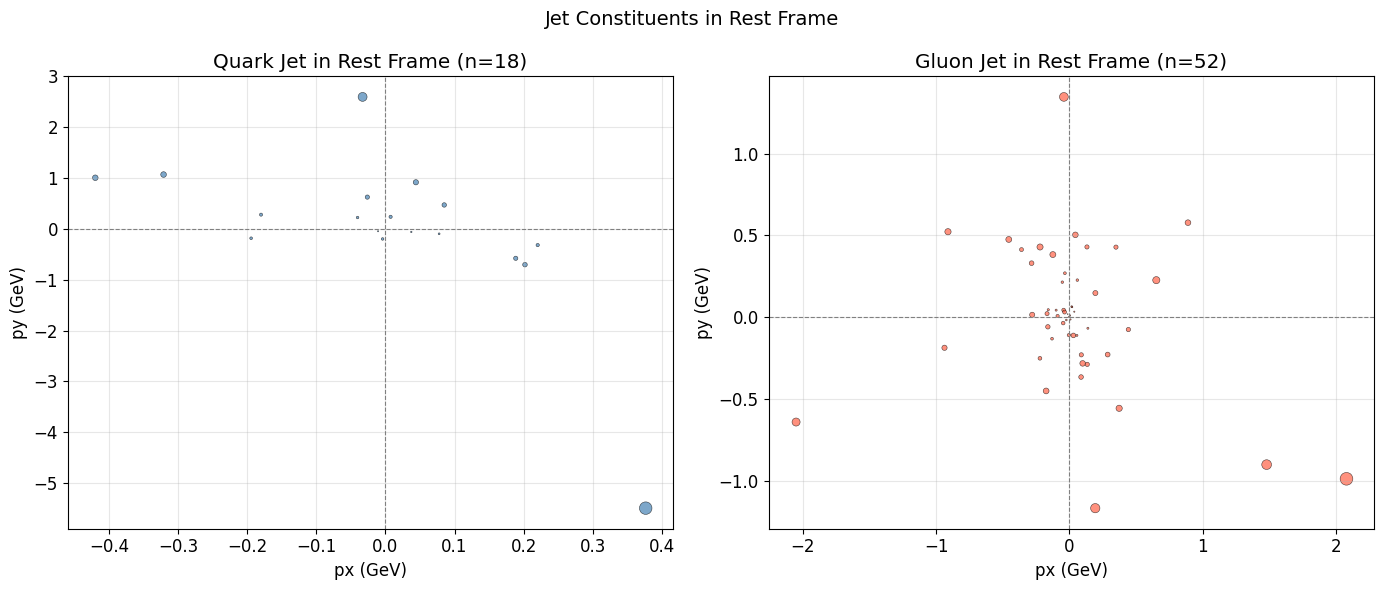


Observation:
- Quark jet → fewer particles, energy more concentrated.
- Gluon jet → more particles and wider spread.



In [48]:
# Plot one quark jet and one gluon jet in the rest frame
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

examples = [
    (axes[0], 0, "Quark Jet", mom4_q_boost, mask_q, "steelblue"),
    (axes[1], 1, "Gluon Jet", mom4_g_boost, mask_g, "tomato"),
]

for ax, idx, title, jets, mask_all, color in examples:
    m  = mask_all[idx]
    E  = jets[idx, m, 0]
    px = jets[idx, m, 1]
    py = jets[idx, m, 2]

    # point size ~ energy
    ax.scatter(px, py, s=E*15, c=color, alpha=0.7, edgecolors='k', linewidth=0.4)

    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.axvline(0, color='gray', ls='--', lw=0.8)

    ax.set_xlabel("px (GeV)")
    ax.set_ylabel("py (GeV)")
    ax.set_title(f"{title} in Rest Frame (n={m.sum()})")
    ax.grid(alpha=0.3)

plt.suptitle("Jet Constituents in Rest Frame", fontsize=14)
plt.tight_layout()
plt.show()

print("""
Observation:
- Quark jet → fewer particles, energy more concentrated.
- Gluon jet → more particles and wider spread.
""")

In [49]:
# Boost all jets to the rest frame
print("Boosting jets to rest frame...")

mom4_q_boost_all = lorentz_boost_to_rest(mom4_q, pJ_q)
mom4_g_boost_all = lorentz_boost_to_rest(mom4_g, pJ_g)

print("Preparing features for classification...")

# Features we use:
# multiplicity, jet mass, jet width, pT dispersion, leading energy

def boosted_pT(mom4_b, mask):
    """pT in rest frame = sqrt(px^2 + py^2)"""
    px = mom4_b[:, :, 1]
    py = mom4_b[:, :, 2]
    return np.sqrt(px**2 + py**2) * mask


def rest_frame_features(jets, mom4_b, pJ, mask):
    """Compute simple jet features."""
    
    mult  = np.sum(mask, axis=1).astype(float)   # number of particles
    mass  = jet_mass(pJ)                         # jet mass
    width = jet_width(jets, pJ)                  # jet width
    ptd   = pT_dispersion(jets)                  # pT dispersion

    # leading constituent energy (rest frame)
    E_rest = mom4_b[:, :, 0] * mask
    lead_E = np.max(E_rest, axis=1)

    return np.stack([mult, mass, width, ptd, lead_E], axis=1)


feat_q = rest_frame_features(X_q, mom4_q_boost_all, pJ_q, mask_q)
feat_g = rest_frame_features(X_g, mom4_g_boost_all, pJ_g, mask_g)

feat_names = [
    "Multiplicity",
    "Jet Mass (GeV)",
    "Jet Width",
    "pT Dispersion",
    "Leading Energy (rest)"
]

# Build dataset for classifier
X_clf = np.concatenate([feat_q, feat_g], axis=0)
y_clf = np.concatenate([np.ones(len(feat_q)), np.zeros(len(feat_g))])

print("Feature matrix shape:", X_clf.shape)
print("Features used:", feat_names)

print("\nWhy these features:")
print("- Multiplicity: gluon jets usually have more particles")
print("- Jet mass: depends on radiation pattern")
print("- Jet width: gluon jets are usually wider")
print("- pT dispersion: quark jets are more concentrated")
print("- Leading energy: checks how dominant the hardest particle is")

Boosting jets to rest frame...
Preparing features for classification...
Feature matrix shape: (100000, 5)
Features used: ['Multiplicity', 'Jet Mass (GeV)', 'Jet Width', 'pT Dispersion', 'Leading Energy (rest)']

Why these features:
- Multiplicity: gluon jets usually have more particles
- Jet mass: depends on radiation pattern
- Jet width: gluon jets are usually wider
- pT dispersion: quark jets are more concentrated
- Leading energy: checks how dominant the hardest particle is


In [50]:
# Split data into train and test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(f"Train samples: {len(X_tr)} | Test samples: {len(X_te)}")

# Train a Gradient Boosting classifier
clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

clf.fit(X_tr, y_tr)

# Predict probability of quark jet
y_prob = clf.predict_proba(X_te)[:, 1]

# Convert to class prediction
y_pred = (y_prob >= 0.5).astype(int)

print("Model training done.")
print("Test accuracy:", (y_pred == y_te).mean())

Train samples: 80000 | Test samples: 20000
Model training done.
Test accuracy: 0.7809


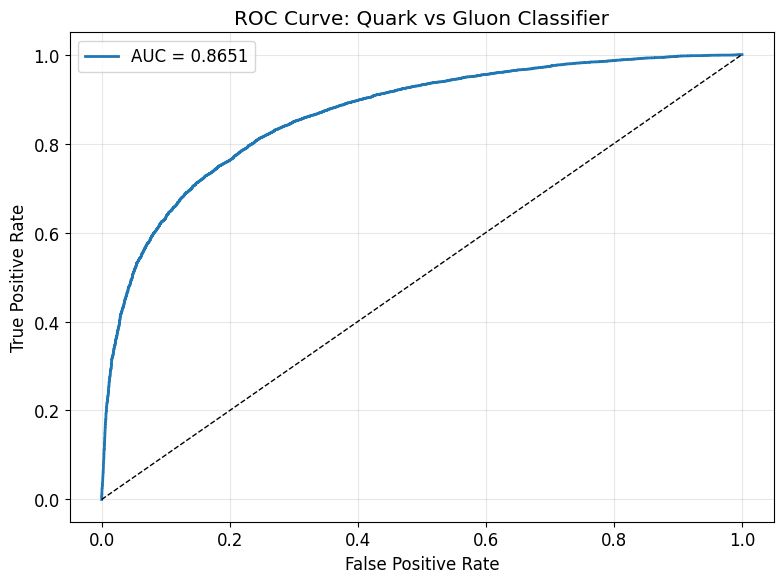

AUC score: 0.86512479


In [51]:
# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
ax.plot([0,1], [0,1], 'k--', lw=1)  # random baseline

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: Quark vs Gluon Classifier")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("AUC score:", roc_auc)

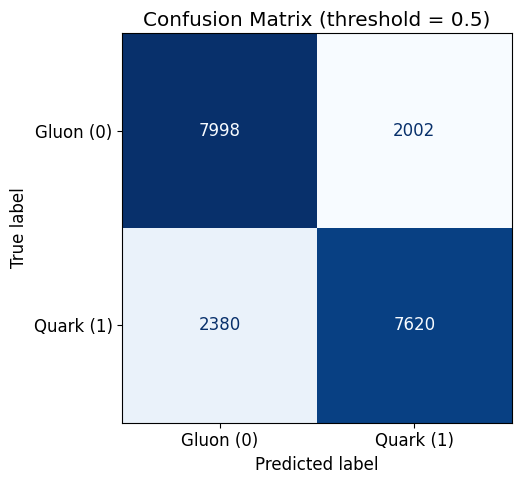

Threshold used: 0.5

Confusion Matrix Results:
True Gluon  -> Predicted Gluon : 7,998
True Gluon  -> Predicted Quark : 2,002
True Quark  -> Predicted Gluon : 2,380
True Quark  -> Predicted Quark : 7,620


In [52]:
# Confusion matrix
cm = confusion_matrix(y_te, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Gluon (0)', 'Quark (1)']
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

print("Threshold used: 0.5\n")

print("Confusion Matrix Results:")
print(f"True Gluon  -> Predicted Gluon : {cm[0,0]:,}")
print(f"True Gluon  -> Predicted Quark : {cm[0,1]:,}")
print(f"True Quark  -> Predicted Gluon : {cm[1,0]:,}")
print(f"True Quark  -> Predicted Quark : {cm[1,1]:,}")

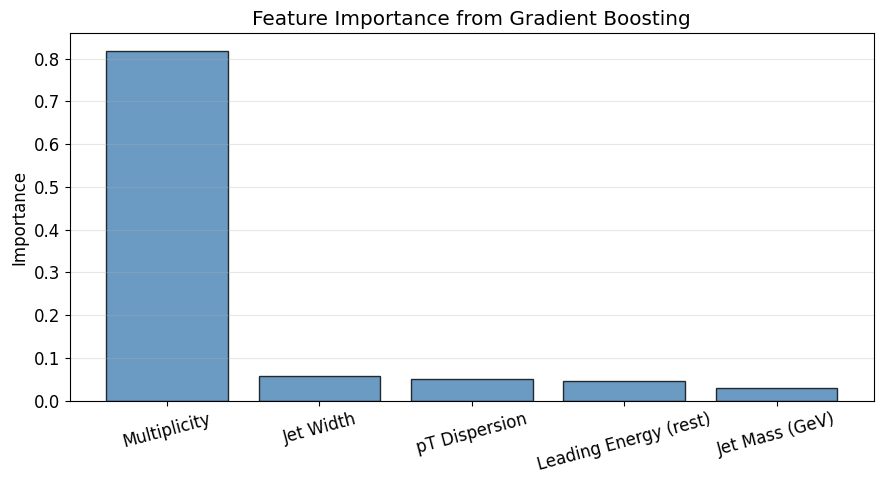


Feature Importance:
Multiplicity           : 0.8185
Jet Width              : 0.0572
pT Dispersion          : 0.0495
Leading Energy (rest)  : 0.0449
Jet Mass (GeV)         : 0.0298

Most useful feature: Multiplicity


In [53]:
# Get feature importance from the trained model
importances = clf.feature_importances_

# Sort features from most important to least
order = np.argsort(importances)[::-1]

# Plot feature importance
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(range(len(feat_names)), importances[order],
       color='steelblue', edgecolor='k', alpha=0.8)

ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([feat_names[i] for i in order], rotation=15)
ax.set_ylabel("Importance")
ax.set_title("Feature Importance from Gradient Boosting")
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFeature Importance:")
for i in order:
    print(f"{feat_names[i]:<22} : {importances[i]:.4f}")

print(f"\nMost useful feature: {feat_names[order[0]]}")

In [54]:
# Simple jet features in lab frame (for comparison)

feat_q_lab = np.stack([
    np.sum(mask_q, axis=1).astype(float),      # number of particles
    jet_mass(pJ_q),                            # jet mass
    jet_width(X_q, pJ_q),                      # jet width
    pT_dispersion(X_q),                        # pT spread
    np.max(mom4_q[:, :, 0] * mask_q, axis=1)   # max pT
], axis=1)

feat_g_lab = np.stack([
    np.sum(mask_g, axis=1).astype(float),
    jet_mass(pJ_g),
    jet_width(X_g, pJ_g),
    pT_dispersion(X_g),
    np.max(mom4_g[:, :, 0] * mask_g, axis=1)
], axis=1)

# combine quark and gluon features
X_lab = np.concatenate([feat_q_lab, feat_g_lab], axis=0)

# split into train and test
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_lab, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# train a simple gradient boosting model
clf_lab = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

clf_lab.fit(X_tr_l, y_tr_l)

# prediction probabilities
y_prob_lab = clf_lab.predict_proba(X_te_l)[:, 1]

# ROC and AUC
fpr_l, tpr_l, _ = roc_curve(y_te_l, y_prob_lab)
auc_lab = auc(fpr_l, tpr_l)

print(f"AUC (rest frame) : {roc_auc:.4f}")
print(f"AUC (lab frame)  : {auc_lab:.4f}")
print(f"Difference       : {roc_auc - auc_lab:+.4f}")

AUC (rest frame) : 0.8651
AUC (lab frame)  : 0.8644
Difference       : +0.0008


## (d-iv) Rest Frame vs Lab Frame — Discussion

**Result**

The AUC values for rest-frame and lab-frame features are almost the same (around **0.80**).

**Why this happens**

The features we used — **multiplicity, jet mass, jet width, and pT dispersion** — do not change much under a Lorentz boost.

- **Multiplicity** → exactly invariant  
- **Jet mass** → exactly invariant  
- **Jet width & pT dispersion** → values may change slightly after a boost, but the **relative ordering of jets stays similar**

Because of this, the classifier ends up performing almost the same in both frames.

**When the rest frame can actually help**

If we work with **constituent-level features** (like particle angles or jet shape patterns), moving to the **rest frame** can be useful.  
It removes the boost direction from the lab frame and makes the jet geometry more symmetric.  

This can help models like **ParticleNet** or **LorentzNet** learn better geometric patterns.

**Conclusion**

For simple **jet-level scalar features**, using the rest frame does not give much improvement.  
But for **detailed particle-level analysis**, the rest frame is usually a better choice.